In [1]:
# Apple Silicon (M1/M2+) GPU support via Metal
# If you installed `tensorflow-macos` and `tensorflow-metal`, this will use GPU:0 automatically.
# Tip: conda/mamba env (example):
#   conda create -n tf-mps python=3.10 -y
#   conda activate tf-mps
#   pip install tensorflow-macos tensorflow-metal
import os, platform, sys
import tensorflow as tf

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)

# Show devices
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print("CPUs:", cpus)
print("GPUs:", gpus)

# Enable memory growth on detected GPUs (Metal backend shows up as GPU:0)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)

if gpus:
    print("Using GPU acceleration (Metal).")
else:
    print("No GPU detected. On Apple Silicon, install `tensorflow-macos` and `tensorflow-metal`.")


Python: 3.10.18
Platform: macOS-26.3.1-arm64-arm-64bit
TensorFlow: 2.16.2
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU acceleration (Metal).


In [2]:
# Optional: Enable mixed precision (can speed up training on Apple GPUs)
# Note: If you see numerical instability, comment this out.
try:
    from tensorflow.keras import mixed_precision
    if tf.config.list_physical_devices('GPU'):
        mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")
    else:
        print("Mixed precision not enabled (no GPU detected).")
except Exception as e:
    print("Could not enable mixed precision:", e)


Mixed precision policy set to 'mixed_float16'.


# Ge'ez → Amharic BLSTM translator (learning notebook)

Trainable **sequence-to-sequence** model: **BiLSTM encoder + attention decoder**.

This notebook is both a **working trainer** and an **NLP study guide** — read the markdown sections and run the visualization cells to see how data, tokens, and learning curves behave on *your* corpus.

**Tip:** Use a GPU runtime (Colab: Runtime → Change runtime type → GPU).

In [3]:
!pip -q install tensorflow==2.19.0 sacrebleu==2.4.0 pandas==2.2.2 numpy==1.26.4 matplotlib --no-warn-script-location
import tensorflow as tf
#@title 2. Reinstall NumPy → TensorFlow → pandas → sacrebleu
# 1. NumPy first (exact version you asked for)
# (Tip) Consider installing these packages in your environment beforehand.

# 2. TensorFlow (will see the NumPy we just installed)
# (Tip) Consider installing these packages in your environment beforehand.

# 3. pandas & sacrebleu
# (Tip) Consider installing these packages in your environment beforehand.

# 4. Quick sanity-check
import numpy as np, pandas as pd, tensorflow as tf, sacrebleu
print(f"NumPy:     {np.__version__}")
print(f"Pandas:    {pd.__version__}")
print(f"TensorFlow:{tf.__version__}")
print(f"SacreBLEU: {sacrebleu.__version__}")
print("All imports succeeded!")
print("\nDevice check:", tf.config.list_physical_devices("GPU"))
if not tf.config.list_physical_devices("GPU"):
    print(" No GPU visible to TensorFlow. On Apple Silicon, install `tensorflow-macos` and `tensorflow-metal`.")


zsh:1: command not found: pip
NumPy:     1.26.4
Pandas:    2.2.2
TensorFlow:2.16.2
SacreBLEU: 2.5.1
All imports succeeded!

Device check: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
#@title Setup (installs & imports)
AUTO_INSTALL_PACKAGES = True  #@param {type:"boolean"}

if AUTO_INSTALL_PACKAGES:
    !python -m pip install --upgrade pip
    !pip -q install tensorflow-macos==2.15.1 tensorflow-metal==1.1.0 sacrebleu==2.4.0 pandas==2.2.2 numpy==1.26.4 matplotlib --no-warn-script-location

import os, math, random, json, pickle, gc
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, AdditiveAttention, Concatenate, TimeDistributed, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras import mixed_precision

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    files = None
    IN_COLAB = False

import sacrebleu
import matplotlib.pyplot as plt

if IN_COLAB:
    print("Colab detected: you can use files.upload().")
else:
    print("Running outside Colab; make sure local data paths exist.")


/Users/metasebiya21/work-projects/geez-amharic-translator/.venv/bin/python: No module named pip
zsh:1: command not found: pip
Running outside Colab; make sure local data paths exist.


In [5]:
print('TensorFlow:', tf.__version__)
try:
    from tensorflow.python.client import device_lib
    print('Devices:', [d.name for d in device_lib.list_local_devices()])
except Exception as e:
    print('Device check skipped:', e)

# Mixed precision often causes NaN loss on Metal with custom masked loss — keep False on M1.
USE_MIXED_PRECISION = False  #@param {type:"boolean"}
if USE_MIXED_PRECISION:
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print("Mixed precision:", mixed_precision.global_policy())
else:
    mixed_precision.set_global_policy("float32")
    print("Mixed precision: disabled (policy=float32)")

# Optional: gradient clipping
CLIP_NORM = 1.0  #@param {type:"number"}


TensorFlow: 2.16.2
Devices: ['/device:CPU:0', '/device:GPU:0']
Mixed precision: disabled (policy=float32)


2026-06-04 09:53:07.287642: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-04 09:53:07.287830: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-04 09:53:07.287851: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-04 09:53:07.288269: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 09:53:07.288292: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


---
## NLP primer — how this notebook fits together

**Machine translation (MT)** maps a source sentence \(x = (x_1,\ldots,x_m)\) to a target sentence \(y = (y_1,\ldots,y_n)\). We learn parameters \(\theta\) from **parallel corpora**: rows where Ge'ez and Amharic mean the same thing.

### Pipeline (what each section does)

```
Raw CSV  →  clean text  →  tokenize (chars/words → IDs)  →  pad batches
    →  Encoder (read Ge'ez)  →  Decoder + Attention (write Amharic)
    →  loss vs gold Amharic  →  update weights  →  greedy decode at test time
```

### Key NLP terms

| Term | Meaning here |
|------|----------------|
| **Corpus** | Your `AGE.csv` parallel sentences |
| **Token** | One symbol the model sees: a **character** (default) or **word** |
| **Vocabulary** | Mapping token → integer ID (`Tokenizer.word_index`) |
| **Sequence length** | Max timesteps after padding (`dyn_max_src`, `dyn_max_tgt`) |
| **Teacher forcing** | During training, decoder input is the *true* previous Amharic tokens (`<s> …`) |
| **Attention** | Decoder looks at *all* encoder states when predicting each Amharic character |
| **Loss** | Masked cross-entropy on real Amharic chars (not padding) |
| **masked_token_accuracy** | Fraction of next-char predictions correct (main training signal) |
| **BLEU** | Automatic metric: n-gram overlap between prediction and reference (higher = better) |

### Char vs word tokenization (important!)

- **Word-level** on biblical text → 50k+ rare types, many seen once → poor generalization.
- **Character-level** → ~300 Ethiopic symbols, shared across all sentences → better for small corpora.

### Overfitting vs underfitting (intuition)

- **Underfitting**: train loss stays high; model too weak or wrong tokens (huge vocab).
- **Overfitting**: train loss ↓ but val loss ↑; memorizes training pairs.
- **Good fit**: both losses decrease and val loss stabilizes at a reasonable level.

Run the cells below in order; plots are generated from *your* data after loading.

## Data sources
Parallel CSVs under `data/` with columns like `amh, gez, eng`. `AGE.csv` has Ge'ez↔Amharic pairs. `Kufale.csv` is Ge'ez↔English only — add it once you have Amharic targets.

In [6]:
#@title Data source (local CSV paths)
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "data").exists() and (repo_root.parent / "data").exists():
    repo_root = repo_root.parent

csv_paths = [
    repo_root / "data" / "AGE.csv",
    # repo_root / "data" / "Kufale.csv",  # gez+eng only; enable after adding `amh`
]  #@param
csv_paths = [Path(p).expanduser() for p in csv_paths]
missing = [p for p in csv_paths if not p.exists()]
if missing:
    raise FileNotFoundError(f"CSV(s) not found: {missing}")

print("Using:")
for p in csv_paths:
    print(" -", p)


Using:
 - /Users/metasebiya21/work-projects/geez-amharic-translator/data/AGE.csv


## Setting the Hyper-Parameters

Character-level training is the default (~350 types vs 50k+ rare words).

**Mac M1 8 GB RAM:** keep `M1_8GB_MODE = True` (smaller batch, shorter sequences, frees NumPy after tf.data). Increase settings only if training is stable and memory allows.

In [35]:
#@title Config
M1_8GB_MODE = True  #@param {type:"boolean"}  # recommended on Mac M1 with 8 GB unified memory
src_col = "gez"  #@param {type:"string"}
tgt_col = "amh"  #@param {type:"string"}
token_level = "char"  #@param ["char", "word"]
sample_frac = None  #@param {type:"number"} # set to None to use the full dataset
epochs = 30  #@param {type:"integer"}
batch_size = 16 if M1_8GB_MODE else 64  #@param {type:"integer"}
max_src_len = 96 if M1_8GB_MODE else 160  #@param {type:"integer"}
max_tgt_len = 96 if M1_8GB_MODE else 160  #@param {type:"integer"}
length_percentile = 95  #@param {type:"integer"}  # cap padding at p95, not absolute max
src_vocab = 512  #@param {type:"integer"}
tgt_vocab = 512  #@param {type:"integer"}
emb_dim = 128 if M1_8GB_MODE else 256  #@param {type:"integer"}
enc_units = 128 if M1_8GB_MODE else 256  #@param {type:"integer"}
dec_units = 128 if M1_8GB_MODE else 256  #@param {type:"integer"}
learning_rate = 3e-4  #@param {type:"number"}
use_adaptive_lr = True  #@param {type:"boolean"}
adaptive_lr_factor = 0.5  #@param {type:"number"}
adaptive_lr_patience = 3  #@param {type:"integer"}
adaptive_lr_min = 1e-5  #@param {type:"number"}
early_stop_patience = 6  #@param {type:"integer"}
max_train_batches = 0  #@param {type:"integer"} # <=0 means auto-fill all batches per epoch
max_val_batches = 0  #@param {type:"integer"} # <=0 means auto-fill all batches per epoch
val_split = 0.1  #@param {type:"number"}
dropout = 0.4  #@param {type:"number"}           # attention concat dropout
emb_dropout = 0.2  #@param {type:"number"}       # after embeddings
recurrent_dropout = 0.2  #@param {type:"number"} # LSTM recurrent (regularization)
label_smoothing = 0.05  #@param {type:"number"}   # 0 = off; try 0.05–0.1
USE_TF_DATA = True  #@param {type:"boolean"}
FREE_ARRAYS_AFTER_PIPELINE = True  #@param {type:"boolean"}  # drop padded NumPy after tf.data is built
TF_DATA_PREFETCH = 1 if M1_8GB_MODE else tf.data.AUTOTUNE  # lower prefetch on 8 GB RAM

# Inference decoding
decode_method = "beam"  #@param ["beam", "greedy"]
beam_width = 5  #@param {type:"integer"}
beam_length_penalty = 1.0  #@param {type:"number"}  # higher → prefer longer outputs (0 = off)
beam_min_length_ratio = 0.45  #@param {type:"number"}  # min output chars ≈ ratio × Ge'ez source length
# Greedy-only: reduce repetition loops if you switch decode_method to greedy
decode_repeat_penalty = 2.5  #@param {type:"number"}
decode_repeat_window = 12  #@param {type:"integer"}
decode_stop_repeat = 3  #@param {type:"integer"}

out_dir = str((repo_root / "artifacts").resolve())
os.makedirs(out_dir, exist_ok=True)

def seed_all(seed=42):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

seed_all(42)
if M1_8GB_MODE:
    print("M1 8GB profile: batch=", batch_size, "emb=", emb_dim, "max_len=", max_src_len)


M1 8GB profile: batch= 16 emb= 128 max_len= 96


## Load & Preview Data

In [8]:

#@title Load & peek
def read_data(csv_paths, src_col, tgt_col, sample_frac=None):
    frames = []
    for csv_path in csv_paths:
        part = pd.read_csv(csv_path)
        if src_col not in part.columns or tgt_col not in part.columns:
            print(f"Skipping {csv_path.name}: missing '{src_col}' or '{tgt_col}' (cols={list(part.columns)})")
            continue
        part = part[[src_col, tgt_col]].dropna()
        part["__source__"] = csv_path.name
        frames.append(part)
    if not frames:
        raise ValueError(f"No usable rows found for columns '{src_col}' and '{tgt_col}'.")
    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates(subset=[src_col, tgt_col]).reset_index(drop=True)
    if sample_frac is not None and 0 < sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=42)
    df[src_col] = df[src_col].astype(str).str.strip()
    df[tgt_col] = df[tgt_col].astype(str).str.strip()
    return df.reset_index(drop=True)

df = read_data(csv_paths, src_col, tgt_col, sample_frac=sample_frac)
print(f"Pairs: {len(df)}")
if "__source__" in df.columns:
    print(df["__source__"].value_counts().to_string())
display(df.head(5))


Pairs: 17416
__source__
AGE.csv    17416


,gez,amh,__source__
0,ወዳዊትሰ ንጉሥ ልህቀ ወኀለፈ መዋዕሊሁ ወይከድንዎ አልባሰ ወኢያመውቆ ።,ንጉሡ ዳዊትም ሸመገለ ዕድሜውም በዛ፤ ልብስም ደረቡለት፥ ነገር ግን አይሞ...,AGE.csv
1,ወይቤሉ ደቁ ለዳዊት ይኅሥሡ ለእግዚእነ ለንጉሥ ወለተ ድንግለ ወያምጽእዋ ...,ባሪያዎቹም። ለጌታችን ለንጉሡ ድንግል ትፈለጋለች፤ በንጉሡም ፊት ቆማ ታገ...,AGE.csv
2,ወኀሠሡ ወለተ ሠናይተ እምነ ኵሉ ደወለ እስራኤል ወረከቡ አቢሳሃ ሰሜናዊት...,በእስራኤልም አገር ሁሉ የተዋበች ቈንጆ ፈለጉ፤ ሱነማይቱን አቢሳንም አገኙ...,AGE.csv
3,ወነበረት ትትለአኮ ወንጉሥሰ ኢያእመራ ።,ቈንጆይቱም እጅግ ውብ ነበረች፤ ንጉሡንም ትረዳውና ታገለግለው ነበር፥ ንጉ...,AGE.csv
4,ወአዶንያስ ወልደ አጊት ተንሥአ ወይቤ አነ እነግሥ ወገብረ ሎቱ ሰረገላተ ...,የአጊትም ልጅ አዶንያስ። ንጉሥ እሆናለሁ ብሎ ተነሣ፤ ሰረገሎችንና ፈረሰኞ...,AGE.csv


### Explore the corpus (before tokenization)

**Parallel data**: each row is one translation pair. Good MT data is *clean* (no empty lines), *aligned* (same meaning), and *diverse* enough vocabulary.

The plots below show:
- **Sentence length** — drives padding and memory (longer → more LSTM steps).
- **Word frequency** — a few tokens dominate; most are rare (Zipf pattern — why char-level helps on small corpora).

/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/ipykernel_4195/3957122948.py:49: UserWarning: Glyph 4821 (\N{ETHIOPIC SYLLABLE PHARYNGEAL E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/ipykernel_4195/3957122948.py:49: UserWarning: Glyph 4781 (\N{ETHIOPIC SYLLABLE KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/ipykernel_4195/3957122948.py:49: UserWarning: Glyph 4877 (\N{ETHIOPIC SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/ipykernel_4195/3957122948.py:49: UserWarning: Glyph 4752 (\N{ETHIOPIC SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/ipykernel_4195/3957122948.py:49: UserWarning: Glyph 4813 (\N{ETHIOPIC SYLLABLE WE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5f/j1l79b713t79d8l1_1shthfw0000gn/T/i

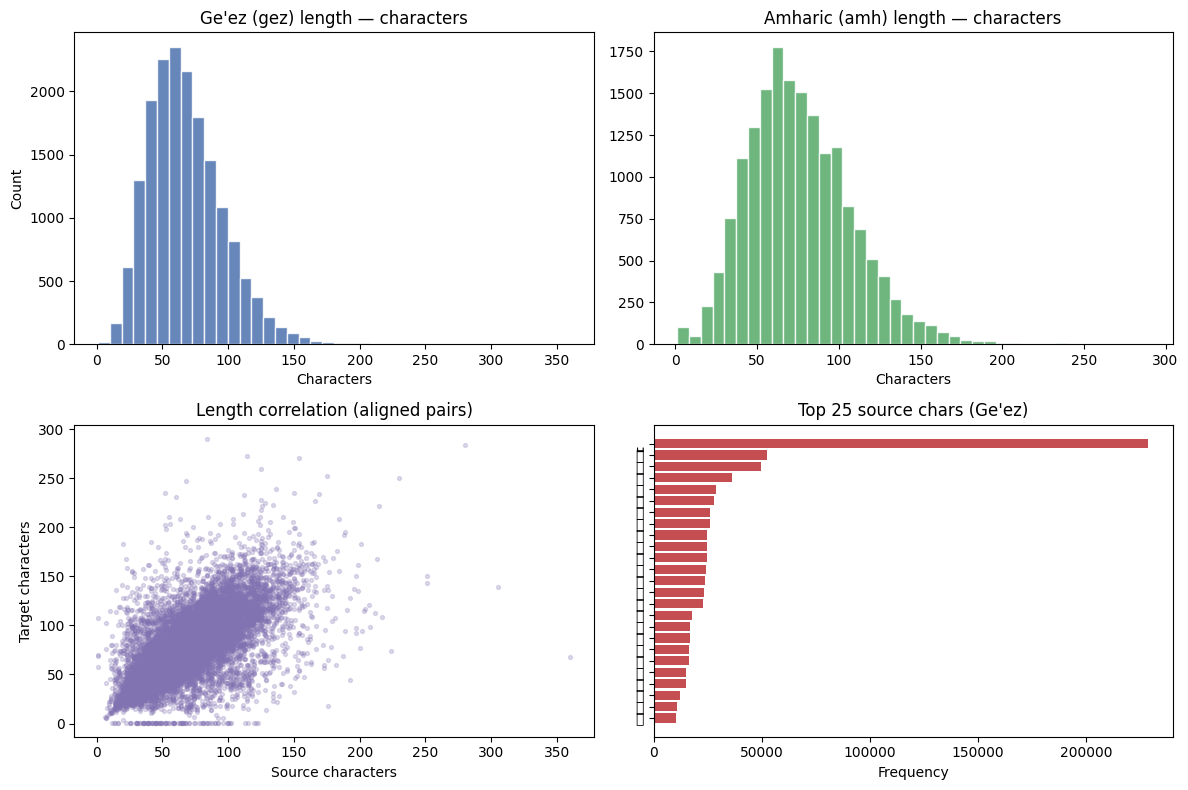

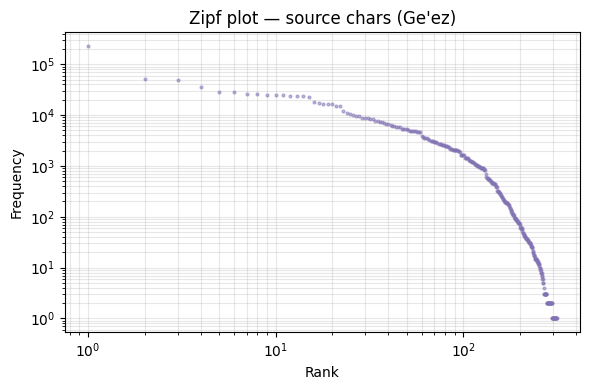

Pairs: 17,416
Unique source chars: 315  |  hapax (count=1): 18 (5.7%)
Length p50 / p95 — src: 64 / 119
Length p50 / p95 — tgt: 73 / 133


In [9]:
#@title Visualize corpus statistics
from collections import Counter

def _tokens(text, level):
    text = str(text).strip()
    return list(text) if level == "char" else text.split()

def _length(text, level):
    text = str(text).strip()
    return len(text) if level == "char" else len(text.split())

def corpus_stats(texts, level):
    lengths = [_length(t, level) for t in texts]
    counter = Counter()
    for t in texts:
        counter.update(_tokens(t, level))
    return lengths, counter

level = token_level  # uses Config
src_lengths, src_counter = corpus_stats(df[src_col], level)
tgt_lengths, tgt_counter = corpus_stats(df[tgt_col], level)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
unit = "characters" if level == "char" else "words"

axes[0, 0].hist(src_lengths, bins=40, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0, 0].set_title(f"Ge'ez ({src_col}) length — {unit}")
axes[0, 0].set_xlabel(unit.capitalize())
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(tgt_lengths, bins=40, color="#55A868", alpha=0.85, edgecolor="white")
axes[0, 1].set_title(f"Amharic ({tgt_col}) length — {unit}")
axes[0, 1].set_xlabel(unit.capitalize())

axes[1, 0].scatter(src_lengths, tgt_lengths, alpha=0.25, s=8, c="#8172B2")
axes[1, 0].set_xlabel(f"Source {unit}")
axes[1, 0].set_ylabel(f"Target {unit}")
axes[1, 0].set_title("Length correlation (aligned pairs)")

top_n = 25
common = src_counter.most_common(top_n)
labels = [w if w.strip() else "␣" for w, _ in common]
axes[1, 1].barh(range(len(labels)), [c for _, c in common][::-1], color="#C44E52")
axes[1, 1].set_yticks(range(len(labels)))
axes[1, 1].set_yticklabels(labels[::-1], fontname="DejaVu Sans")
axes[1, 1].set_title(f"Top {top_n} source {level}s (Ge'ez)")
axes[1, 1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

# Zipf: rank vs frequency (log-log) — straight line ≈ natural language
freqs = sorted(src_counter.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.loglog(ranks, freqs, ".", alpha=0.5, color="#8172B2", markersize=4)
ax2.set_xlabel("Rank")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Zipf plot — source {level}s (Ge'ez)")
ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

hapax = sum(1 for _, c in src_counter.items() if c == 1)
print(f"Pairs: {len(df):,}")
print(f"Unique source {level}s: {len(src_counter):,}  |  hapax (count=1): {hapax:,} ({100*hapax/max(1,len(src_counter)):.1f}%)")
print(f"Length p50 / p95 — src: {np.percentile(src_lengths,50):.0f} / {np.percentile(src_lengths,95):.0f}")
print(f"Length p50 / p95 — tgt: {np.percentile(tgt_lengths,50):.0f} / {np.percentile(tgt_lengths,95):.0f}")

## Tokenization
Default **character-level** tokenization (recommended): ~350 types instead of 50k+ rare words. Word-level is kept for experiments. Targets use single-char BOS/EOS (`\u241e` / `\u241f`) at char level — **not** the string `<s>` (that splits into three tokens and breaks training).

In [10]:

#@title Tokenizers
# Single-char BOS/EOS for char-level (string "<s>" splits into 3 tokens and breaks alignment).
BOS_CHAR = "\u241e"
EOS_CHAR = "\u241f"

def _seq_len(text, level="char"):
    return len(text) if level == "char" else len(text.split())

def target_bos_eos_ids(tgt_tok, char_level=None):
    char_level = getattr(tgt_tok, "char_level", False) if char_level is None else char_level
    if char_level:
        bos = tgt_tok.word_index.get(BOS_CHAR)
        eos = tgt_tok.word_index.get(EOS_CHAR)
    else:
        bos = tgt_tok.word_index.get("<s>")
        eos = tgt_tok.word_index.get("</s>")
    return bos, eos

def prepare_tokenizers(src_texts, tgt_texts, num_words_src=512, num_words_tgt=512, oov_token="<unk>", level="char"):
    char_level = level == "char"
    tok_kwargs = dict(num_words=num_words_src, filters="", lower=False, oov_token=oov_token, char_level=char_level)
    if not char_level:
        tok_kwargs["split"] = " "
    src_tok = Tokenizer(**tok_kwargs)
    tgt_kwargs = dict(tok_kwargs)
    tgt_kwargs["num_words"] = num_words_tgt
    tgt_tok = Tokenizer(**tgt_kwargs)
    if char_level:
        tgt_in_texts  = [BOS_CHAR + t for t in tgt_texts]
        tgt_out_texts = [t + EOS_CHAR for t in tgt_texts]
    else:
        tgt_in_texts  = [f"<s> {t}" for t in tgt_texts]
        tgt_out_texts = [f"{t} </s>" for t in tgt_texts]
    src_tok.fit_on_texts(src_texts)
    tgt_tok.fit_on_texts(tgt_in_texts + tgt_out_texts)
    bos_id, eos_id = target_bos_eos_ids(tgt_tok, char_level)
    if bos_id is None or eos_id is None:
        raise RuntimeError("BOS/EOS missing from target vocabulary — check token_level and fit data.")
    return src_tok, tgt_tok, tgt_in_texts, tgt_out_texts

src_tok, tgt_tok, tgt_in_texts, tgt_out_texts = prepare_tokenizers(
    df[src_col].tolist(), df[tgt_col].tolist(), src_vocab, tgt_vocab, level=token_level
)

# dynamic lengths — p95 cap so one outlier sentence does not blow up RAM
_src_lens = [_seq_len(s, token_level) for s in df[src_col]]
_tgt_lens = [_seq_len(s, token_level) + (2 if token_level == "char" else 3) for s in df[tgt_col]]
dyn_max_src = min(max_src_len, int(np.percentile(_src_lens, length_percentile)))
dyn_max_tgt = min(max_tgt_len, int(np.percentile(_tgt_lens, length_percentile)))
dyn_max_src = max(dyn_max_src, 4)
dyn_max_tgt = max(dyn_max_tgt, 4)
print(f"Length caps (p{length_percentile}): src={dyn_max_src}, tgt={dyn_max_tgt}  (max was {max(_src_lens)}/{max(_tgt_lens)})")

def texts_to_padded(tokenizer, texts, maxlen):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")

X_src = texts_to_padded(src_tok, df[src_col].tolist(), dyn_max_src)
X_tgt_in = texts_to_padded(tgt_tok, tgt_in_texts, dyn_max_tgt)
X_tgt_out = texts_to_padded(tgt_tok, tgt_out_texts, dyn_max_tgt)
y = np.expand_dims(X_tgt_out, -1).astype("int32")

print("dyn_max_src:", dyn_max_src, "dyn_max_tgt:", dyn_max_tgt)
print("src vocab size:", min(src_vocab, len(src_tok.word_index)+1))
print("tgt vocab size:", min(tgt_vocab, len(tgt_tok.word_index)+1))
tgt_non_pad = (X_tgt_out != 0).mean()
print(f"Target positions that are real chars (not pad): {tgt_non_pad:.1%} — loss must ignore the rest")
_tin = tgt_tok.texts_to_sequences([tgt_in_texts[0]])[0]
_tout = tgt_tok.texts_to_sequences([tgt_out_texts[0]])[0]
assert _tin[1:] == _tout[:-1], "Decoder input/output misaligned — re-run Tokenizers cell"
print(f"BOS id={target_bos_eos_ids(tgt_tok)[0]}, EOS id={target_bos_eos_ids(tgt_tok)[1]} (teacher-forcing shift OK)")


Length caps (p95): src=96, tgt=96  (max was 360/292)
dyn_max_src: 96 dyn_max_tgt: 96
src vocab size: 317
tgt vocab size: 341
Target positions that are real chars (not pad): 74.1% — loss must ignore the rest
BOS id=41, EOS id=42 (teacher-forcing shift OK)


In [11]:
#@title Build tf.data pipelines (optional)
TF_DATA_BUFFER = 512 if M1_8GB_MODE else 4096  #@param {type:"integer"}

train_dataset = None
val_dataset = None
data_size = len(X_src)

train_cap = None if max_train_batches is None or max_train_batches <= 0 else int(max_train_batches)
val_cap = None if max_val_batches is None or max_val_batches <= 0 else int(max_val_batches)

if USE_TF_DATA:
    if data_size == 0:
        raise ValueError("No samples to build datasets.")
    if not 0 < val_split < 1:
        raise ValueError("val_split must be between 0 and 1 when USE_TF_DATA is True.")
    val_count = max(1, int(data_size * val_split))
    train_count = data_size - val_count
    if train_count <= 0:
        raise ValueError("val_split too high for current dataset size.")
    rng = np.random.default_rng(42)
    idx = rng.permutation(data_size)
    train_idx = idx[:train_count]
    val_idx = idx[train_count:]

    def make_dataset(indices, training=True):
        ds = tf.data.Dataset.from_tensor_slices(((X_src[indices], X_tgt_in[indices]), y[indices]))
        if training:
            ds = ds.shuffle(min(TF_DATA_BUFFER, len(indices)), seed=42, reshuffle_each_iteration=True)
        ds = ds.batch(batch_size).prefetch(TF_DATA_PREFETCH)
        return ds

    train_dataset = make_dataset(train_idx, training=True)
    val_dataset = make_dataset(val_idx, training=False)

    if train_cap is not None:
        train_dataset = train_dataset.take(max(1, train_cap))
    if val_cap is not None:
        val_dataset = val_dataset.take(max(1, val_cap))

    if FREE_ARRAYS_AFTER_PIPELINE:
        del X_src, X_tgt_in, X_tgt_out, y
        gc.collect()
        print("Freed padded NumPy arrays — training uses tf.data only.")

if train_dataset is None:
    print("Using NumPy arrays directly (validation_split handled in model.fit).")
else:
    def _fmt_batches(ds):
        card = tf.data.experimental.cardinality(ds).numpy()
        return 'unknown' if card < 0 else int(card)
    print(f"tf.data pipelines ready → train batches: {_fmt_batches(train_dataset)}, val batches: {_fmt_batches(val_dataset)}")


2026-06-04 09:53:11.253811: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 09:53:11.253846: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Freed padded NumPy arrays — training uses tf.data only.
tf.data pipelines ready → train batches: 980, val batches: 109


### Tokenization in practice

1. **Text → integer IDs** — neural nets need numbers; `0` is padding.
2. **Special tokens** — `<s>` starts the target; `</s>` ends it; `<unk>` = unknown.
3. **Padding** — batches are rectangles; shorter sentences get `0` at the end.
4. **Teacher forcing** — decoder input at step \(t\) is the *gold* token at \(t{-}1\), not the model's guess.

**Example** (character level): Ge'ez string → list of char IDs; Amharic target gets `<s>` prepended for input and `</s>` appended for the label we predict.

SOURCE (Ge'ez): ወዳዊትሰ ንጉሥ ልህቀ ወኀለፈ መዋዕሊሁ ወይከድንዎ አልባሰ ወኢያመውቆ ። 
IDs: [3, 64, 80, 16, 27, 2, 6, 100, 48, 2, 21, 68, 44, 2, 3, 39, 7, 55, 2, 10, 62, 26, 84, 40, 2, 3, 13, 18, 28, 6, 54, 2, 5, 21, 59, 27, 2, 3, 33, 37] …
Tokens: ['ወ', 'ዳ', 'ዊ', 'ት', 'ሰ', ' ', 'ን', 'ጉ', 'ሥ', ' ', 'ል', 'ህ', 'ቀ', ' ', 'ወ', 'ኀ', 'ለ', 'ፈ', ' ', 'መ', 'ዋ', 'ዕ', 'ሊ', 'ሁ', ' ', 'ወ', 'ይ', 'ከ', 'ድ', 'ን', 'ዎ', ' ', 'አ', 'ል', 'ባ', 'ሰ', ' ', 'ወ', 'ኢ', 'ያ']

TARGET IN (decoder input): ␞ንጉሡ ዳዊትም ሸመገለ ዕድሜውም በዛ፤ ልብስም ደረቡለት፥ ነገር ግን አይሞቀውም ነበር።
IDs: [41, 4, 97, 153, 2, 50, 99, 11, 5, 2, 126, 19, 35, 12, 2, 104, 25, 133, 10, 5, 2, 7, 86, 33, 2, 13, 23, 14, 5, 2, 20, 38, 94, 12, 11, 32, 2, 18, 35, 9]

TARGET OUT (labels): ንጉሡ ዳዊትም ሸመገለ ዕድሜውም በዛ፤ ልብስም ደረቡለት፥ ነገር ግን አይሞቀውም ነበር።␟
IDs: [4, 97, 153, 2, 50, 99, 11, 5, 2, 126, 19, 35, 12, 2, 104, 25, 133, 10, 5, 2, 7, 86, 33, 2, 13, 23, 14, 5, 2, 20, 38, 94, 12, 11, 32, 2, 18, 35, 9, 2]

Word-level types (full corpus): 115,557
Char-level types (src+tgt): 656


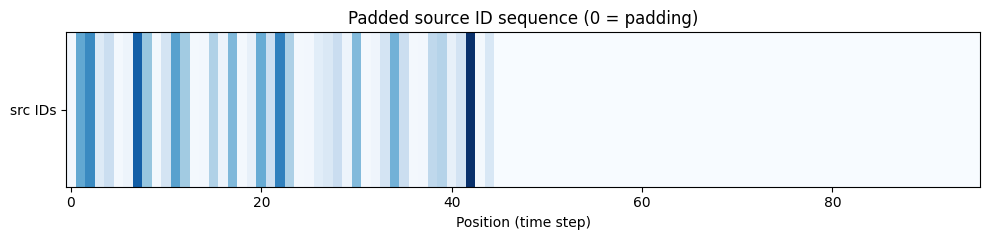

In [12]:
#@title Visualize tokenization (one example)
example_idx = 0  #@param {type:"integer"}
src_text = df.iloc[example_idx][src_col]
tgt_text = df.iloc[example_idx][tgt_col]

src_ids = src_tok.texts_to_sequences([src_text])[0]
tgt_in_ids = tgt_tok.texts_to_sequences([tgt_in_texts[example_idx]])[0]
tgt_out_ids = tgt_tok.texts_to_sequences([tgt_out_texts[example_idx]])[0]

idx2src = {i: w for w, i in src_tok.word_index.items()}
idx2tgt = {i: w for w, i in tgt_tok.word_index.items()}
idx2src[0] = idx2tgt[0] = "<pad>"

def ids_to_symbols(ids, idx2word):
    return [idx2word.get(i, "<unk>") for i in ids]

print("SOURCE (Ge'ez):", src_text[:120], ("…" if len(src_text) > 120 else ""))
print("IDs:", src_ids[:40], ("…" if len(src_ids) > 40 else ""))
print("Tokens:", ids_to_symbols(src_ids, idx2src)[:40])
print()
print("TARGET IN (decoder input):", tgt_in_texts[example_idx][:80])
print("IDs:", tgt_in_ids[:40])
print()
print("TARGET OUT (labels):", tgt_out_texts[example_idx][:80])
print("IDs:", tgt_out_ids[:40])

if token_level == "char":
    word_tok = Tokenizer(filters="", lower=False, oov_token="<unk>", split=" ")
    word_tok.fit_on_texts(df[src_col].tolist() + df[tgt_col].tolist())
    print(f"\nWord-level types (full corpus): {len(word_tok.word_index):,}")
    print(f"Char-level types (src+tgt): {len(src_tok.word_index) + len(tgt_tok.word_index):,}")

fig, ax = plt.subplots(figsize=(10, 2.5))
row = src_ids + [0] * max(0, dyn_max_src - len(src_ids))
ax.imshow([row[:dyn_max_src]], aspect="auto", cmap="Blues")
ax.set_yticks([0])
ax.set_yticklabels(["src IDs"])
ax.set_xlabel("Position (time step)")
ax.set_title("Padded source ID sequence (0 = padding)")
plt.tight_layout()
plt.show()

## Model: BLSTM Encoder + Attention Decoder

In [13]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision
import tensorflow as tf

# Always float32 here — mixed_float16 + masked loss caused NaN weights on Metal.
mixed_precision.set_global_policy("float32")

MODEL_CUSTOM_OBJECTS = {
    "masked_sparse_ce": None,  # filled after defs below
    "masked_token_accuracy": None,
}

def _apply_src_mask_fp32(scores, src_mask):
    s32 = tf.cast(scores, tf.float32)
    m32 = tf.cast(src_mask, tf.float32)
    m32 = tf.expand_dims(m32, axis=1)
    s32 = s32 + (1.0 - m32) * (-1e4)          # avoid -inf in fp16
    return s32

def _softmax_fp32(logits, axis=-1):
    return tf.nn.softmax(tf.cast(logits, tf.float32), axis=axis)

def _target_ids(y_true):
    """Sparse labels as int32 (Keras/tf.data may deliver float32)."""
    return tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)

def masked_sparse_ce(y_true, y_pred):
    """Cross-entropy only on non-padding target positions (id != 0)."""
    y_true = _target_ids(y_true)
    y_pred = tf.cast(y_pred, tf.float32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        y_true, y_pred, from_logits=True
    )
    loss = loss * mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)

def masked_token_accuracy(y_true, y_pred):
    y_true = _target_ids(y_true)
    mask = tf.not_equal(y_true, 0)
    pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    correct = tf.logical_and(tf.equal(pred, y_true), mask)
    return tf.reduce_sum(tf.cast(correct, tf.float32)) / (
        tf.reduce_sum(tf.cast(mask, tf.float32)) + 1e-8
    )

def make_masked_loss(label_smoothing=0.0):
    if label_smoothing <= 0:
        return masked_sparse_ce
    def _loss(y_true, y_pred):
        y_true = _target_ids(y_true)
        y_pred = tf.cast(y_pred, tf.float32)
        mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
        vocab = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_clipped = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        smooth_val = label_smoothing / vocab
        y_smooth = y_clipped * (1.0 - label_smoothing) + smooth_val
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        loss = -tf.reduce_sum(y_smooth * log_probs, axis=-1)
        loss = loss * mask
        return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-8)
    return _loss

MODEL_CUSTOM_OBJECTS["masked_sparse_ce"] = masked_sparse_ce
MODEL_CUSTOM_OBJECTS["masked_token_accuracy"] = masked_token_accuracy

def assert_model_weights_finite(model):
    """Raise if checkpoint/model has NaN weights (broken training)."""
    for v in model.trainable_weights:
        arr = v.numpy()
        if not np.isfinite(arr).all():
            raise RuntimeError(
                f"Model weights are NaN/Inf (layer {v.name}). "
                "Restart kernel → USE_MIXED_PRECISION=False → re-run Tokenizers, "
                "Build model, Train until loss is finite and masked_token_accuracy > 0."
            )

class NoMask(Layer):
    def call(self, x):
        return x
    def compute_mask(self, inputs, mask=None):
        # Explicitly drop mask so nothing downstream receives it
        return None

MODEL_CUSTOM_OBJECTS["NoMask"] = NoMask

def build_model(
    src_vocab_size, tgt_vocab_size,
    emb_dim=192, enc_units=192, dec_units=192,
    max_src_len=80, max_tgt_len=80, dropout=0.2, emb_dropout=0.0, recurrent_dropout=0.0,
    clip_norm=1.0, learning_rate=3e-4, label_smoothing=0.0,
):
    src_in = Input(shape=(max_src_len,), name="src_in")
    tgt_in = Input(shape=(max_tgt_len,), name="tgt_in")

    enc_emb = Dropout(emb_dropout, name="src_emb_dropout")(
        Embedding(src_vocab_size, emb_dim, mask_zero=False, name="src_emb")(src_in)
    )
    dec_emb = Dropout(emb_dropout, name="tgt_emb_dropout")(
        Embedding(tgt_vocab_size, emb_dim, mask_zero=False, name="tgt_emb")(tgt_in)
    )

    enc_blstm, f_h, f_c, b_h, b_c = Bidirectional(
        LSTM(enc_units, return_sequences=True, return_state=True,
             implementation=2, dropout=0.0, recurrent_dropout=recurrent_dropout, name="enc_lstm"),
        name="bilstm"
    )(enc_emb)

    state_h = Concatenate(name="enc_state_h")([f_h, b_h])
    state_c = Concatenate(name="enc_state_c")([f_c, b_c])
    state_h = Dense(dec_units, activation="tanh", name="map_h")(state_h)
    state_c = Dense(dec_units, activation="tanh", name="map_c")(state_c)

    dec_out, _, _ = LSTM(dec_units, return_sequences=True, return_state=True,
                         implementation=2, dropout=0.0, recurrent_dropout=recurrent_dropout,
                         name="dec_lstm")(dec_emb, initial_state=[state_h, state_c])

    # Dot-product attention — one matmul (B,Tq,Tk). Avoids slow (B,Tq,Tk,D) broadcast.
    Wq = TimeDistributed(Dense(dec_units, use_bias=False), name="Wq")(dec_out)      # (B, Tq, D)
    Wk = TimeDistributed(Dense(dec_units, use_bias=False), name="Wk")(enc_blstm)    # (B, Tk, D)
    e = Lambda(lambda xs: tf.matmul(xs[0], xs[1], transpose_b=True), name="attn_scores")([Wq, Wk])

    tgt_mask = Lambda(lambda x: tf.not_equal(x, 0), name="tgt_mask")(tgt_in)
    src_mask = Lambda(lambda x: tf.not_equal(x, 0), name="src_mask")(src_in)

    e_masked_fp32 = Lambda(lambda xs: _apply_src_mask_fp32(xs[0], xs[1]),
                           name="apply_src_mask")([e, src_mask])

    alphas = Lambda(lambda x: _softmax_fp32(x, axis=-1), name="alphas")(e_masked_fp32)  # (B,Tq,Tk)

    context = Lambda(lambda x: tf.matmul(x[0], x[1]), name="context")([alphas, enc_blstm])  # (B,Tq,2*enc_units)

    def _mask_context(args):
        ctx, qmask = args
        qmask = tf.cast(qmask, ctx.dtype)
        return ctx * tf.expand_dims(qmask, axis=-1)

    context = Lambda(_mask_context, name="mask_context")([context, tgt_mask])

    comb = Concatenate(name="attn_concat")([dec_out, context])
    comb = Dropout(dropout, name="dropout")(comb)
    comb = NoMask(name="drop_mask")(comb)

    logits = TimeDistributed(Dense(tgt_vocab_size, dtype="float32"), name="logits")(comb)

    model = Model([src_in, tgt_in], logits)

    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clip_norm or None)
    loss_fn = make_masked_loss(label_smoothing)
    MODEL_CUSTOM_OBJECTS["masked_sparse_ce"] = loss_fn
    model.compile(
        optimizer=opt,
        loss=loss_fn,
        metrics=[masked_token_accuracy],
    )
    return model


### Model architecture (seq2seq + attention)

```mermaid
flowchart LR
  subgraph enc [Encoder BiLSTM]
    G[Ge'ez char IDs] --> E[Embeddings]
    E --> B[BiLSTM]
  end
  subgraph dec [Decoder LSTM]
    A[Amharic input IDs] --> DE[Embeddings]
    DE --> D[LSTM]
  end
  B -->|all hidden states| Att[Attention]
  D --> Att
  Att -->|context vector| Out[Softmax over vocab]
```

- **Encoder** reads the full Ge'ez sentence left-to-right *and* right-to-left (bidirectional), producing a vector per source position.
- **Attention** uses dot-product scores via one `matmul` (layer `attn_scores`) — fast on Metal.
- **Decoder** is unidirectional: it generates Amharic one token at a time.
- **Output layer** predicts a probability distribution over the next character (vocab size ≈ 300–500 with char-level).

**Loss**: masked cross-entropy on **non-padding** target chars only (padding id `0` is ignored). Watch **`masked_token_accuracy`** during training — aim for **>0.35** before translations look reasonable. Unmasked loss looked ~2.8 while the model mostly learned to predict padding.

In [14]:
model = build_model(
    src_vocab_size=min(src_vocab, len(src_tok.word_index)+1),
    tgt_vocab_size=min(tgt_vocab, len(tgt_tok.word_index)+1),
    emb_dim=emb_dim, enc_units=enc_units, dec_units=dec_units,
    max_src_len=dyn_max_src, max_tgt_len=dyn_max_tgt,
    dropout=dropout, emb_dropout=emb_dropout, recurrent_dropout=recurrent_dropout,
    clip_norm=CLIP_NORM, learning_rate=learning_rate, label_smoothing=label_smoothing,
)
print(f"Optimizer: Adam, lr={learning_rate} | dropout={dropout} emb={emb_dropout} lstm_rec={recurrent_dropout} ls={label_smoothing}")
model.summary()


Optimizer: Adam, lr=0.0003


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ src_in (InputLayer) │ (None, 96)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_emb (Embedding) │ (None, 96, 128)   │     40,576 │ src_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ [(None, 96, 256), │    263,168 │ src_emb[0][0]     │
│ (Bidirectional)     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tgt_in (InputLayer) │ (None, 96)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_state_h         │ (None, 256)       │          0 │ bilstm[0][1],     │
│ (Concatenate)       │                   │            │ bilstm[0][3]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_state_c         │ (None, 256)       │          0 │ bilstm[0][2],     │
│ (Concatenate)       │                   │            │ bilstm[0][4]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tgt_emb (Embedding) │ (None, 96, 128)   │     43,648 │ tgt_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ map_h (Dense)       │ (None, 128)       │     32,896 │ enc_state_h[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ map_c (Dense)       │ (None, 128)       │     32,896 │ enc_state_c[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm (LSTM)     │ [(None, 96, 128), │    131,584 │ tgt_emb[0][0],    │
│                     │ (None, 128),      │            │ map_h[0][0],      │
│                     │ (None, 128)]      │            │ map_c[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wq                  │ (None, 96, 128)   │     16,384 │ dec_lstm[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Wk                  │ (None, 96, 128)   │     32,768 │ bilstm[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_scores         │ (None, 96, 96)    │          0 │ Wq[0][0],         │
│ (Lambda)            │                   │            │ Wk[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_mask (Lambda)   │ (None, 96)        │          0 │ src_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ apply_src_mask      │ (None, 96, 96)    │          0 │ attn_scores[0][0… │
│ (Lambda)            │                   │            │ src_mask[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alphas (Lambda)     │ (None, 96, 96)    │          0 │ apply_src_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context (Lambda)    │ (None, 96, 256)   │          0 │ alphas[0][0],     │
│                     │                   │            │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tgt_mask (Lambda)   │ (None, 96)        │          0 │ tgt_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 725,205 (2.77 MB)

 Trainable params: 725,205 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Labels are prepared in the tokenization cell (int32).
# If FREE_ARRAYS_AFTER_PIPELINE freed NumPy tensors, training uses tf.data only.
if globals().get("train_dataset") is not None:
    print("Labels live inside tf.data — no separate `y` array needed.")
elif "X_tgt_out" in globals():
    y = np.expand_dims(X_tgt_out, -1).astype("int32")
    print("y shape:", y.shape, y.dtype)
else:
    raise RuntimeError("Run tokenization (and optionally tf.data) cells first.")


Labels live inside tf.data — no separate `y` array needed.


In [16]:
opt = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=CLIP_NORM)


## Train

**Stop a run immediately** if epoch 1 takes more than ~15–20 minutes on M1 8 GB — that usually means the old slow attention model is still in memory.

**Before training:** run the **Speed benchmark** cell below. You want **under ~2 s/step** (batch 16). If it is 30+ s/step, re-run **Build model** (must show `attn_scores`, not `expand_Wq` / `e_tanh` in summary).

**Is it learning?** Watch `masked_token_accuracy` (not raw loss alone). Random guess ≈ `1/vocab` (~0.3%). After a few epochs you want **>20%**; **>35%** before greedy translations start to look like Amharic. If you see **`loss: nan`** or **`learning_rate: 0`**, stop — set `USE_MIXED_PRECISION = False`, restart kernel, rebuild model, train again.

**Restart kernel** after changing the model cell, then re-run Config → data → tokenize → tf.data → **Build model** → benchmark → train.

Callbacks: **EarlyStopping**, **ModelCheckpoint**, **ReduceLROnPlateau**.

In [17]:
#@title Speed benchmark (run before full training)
import time

_layer_names = [l.name for l in model.layers]
if "attn_scores" not in _layer_names:
    raise RuntimeError(
        "Slow attention model in memory (no attn_scores layer). "
        "Re-run Build model — summary must NOT list expand_Wq or e_tanh."
    )

if train_dataset is None:
    raise RuntimeError("Build tf.data pipeline first.")

_batch = next(iter(train_dataset.take(1)))

_t0 = time.perf_counter()
model.train_on_batch(_batch[0], _batch[1])
_first = time.perf_counter() - _t0

_t0 = time.perf_counter()
for _ in range(3):
    model.train_on_batch(_batch[0], _batch[1])
_warm = (time.perf_counter() - _t0) / 3

_steps = max(1, int(len(df) * (1 - val_split) / batch_size))
print(f"First batch: {_first:.1f}s  |  Warm avg: {_warm:.1f}s")
print(f"Estimated epoch time: ~{_steps * _warm / 60:.0f} min ({_steps} steps)")
if _warm > 5:
    print("WARNING: >5s/step is too slow — interrupt and re-build model.")
elif _warm < 2:
    print("OK — safe to start full training.")

2026-06-04 09:53:15.011825: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


First batch: 20.0s  |  Warm avg: 0.4s
Estimated epoch time: ~6 min (979 steps)
OK — safe to start full training.


In [18]:
#@title Train
ckpt_path = os.path.join(out_dir, "best_model.keras")
callbacks=[
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=early_stop_patience, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, save_weights_only=False)
]

if use_adaptive_lr:
    callbacks.append(
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=adaptive_lr_factor,
            patience=adaptive_lr_patience,
            min_lr=adaptive_lr_min,
            verbose=1
        )
    )

fit_kwargs = dict(epochs=epochs, callbacks=callbacks, verbose=1)

train_cap = None if max_train_batches is None or max_train_batches <= 0 else int(max_train_batches)
if train_cap is not None:
    n_train = int(data_size * (1.0 - val_split)) if 'data_size' in dir() else int(len(df) * (1.0 - val_split))
    batches_per_epoch = max(1, math.ceil(n_train / batch_size))
    fit_kwargs["steps_per_epoch"] = min(train_cap, batches_per_epoch)

if train_dataset is not None and val_dataset is not None:
    if train_cap is not None:
        fit_kwargs["steps_per_epoch"] = max(1, train_cap)
    if val_cap is not None:
        fit_kwargs["validation_steps"] = max(1, val_cap)
    history = model.fit(train_dataset, validation_data=val_dataset, **fit_kwargs)
    _last = history.history.get("loss", [float("nan")])[-1]
    _acc = history.history.get("masked_token_accuracy", [0.0])[-1]
    if not np.isfinite(_last) or _acc <= 0:
        print("WARNING: training unhealthy (loss=%s, masked_token_accuracy=%s). "
              "Do not use best_model.keras for translation — restart kernel and retrain." % (_last, _acc))
else:
    if 'X_src' not in dir():
        raise RuntimeError("Arrays were freed; set FREE_ARRAYS_AFTER_PIPELINE=False or USE_TF_DATA=True.")
    history = model.fit(
        [X_src, X_tgt_in], y,
        validation_split=val_split,
        batch_size=batch_size,
        **fit_kwargs
    )
print("Best checkpoint saved to:", ckpt_path)


Epoch 1/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 289s 286ms/step - loss: 3.7102 - masked_token_accuracy: 0.2312 - val_loss: 3.2682 - val_masked_token_accuracy: 0.2950 - learning_rate: 3.0000e-04
Epoch 2/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 300s 306ms/step - loss: 3.1689 - masked_token_accuracy: 0.3051 - val_loss: 2.9866 - val_masked_token_accuracy: 0.3295 - learning_rate: 3.0000e-04
Epoch 3/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 451s 459ms/step - loss: 2.9542 - masked_token_accuracy: 0.3376 - val_loss: 2.8197 - val_masked_token_accuracy: 0.3622 - learning_rate: 3.0000e-04
Epoch 4/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 256s 261ms/step - loss: 2.8216 - masked_token_accuracy: 0.3597 - val_loss: 2.7078 - val_masked_token_accuracy: 0.3787 - learning_rate: 3.0000e-04
Epoch 5/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 274s 279ms/step - loss: 2.7273 - masked_token_accuracy: 0.3756 - val_loss: 2.6284 - val_masked_token_accuracy: 0.3941 - learning_rate: 3.0000e-04
Epoch 6/30
980/980 ━━━━━━━━━━━━━━━━━━━━ 268s 274ms/step - loss: 2.6529

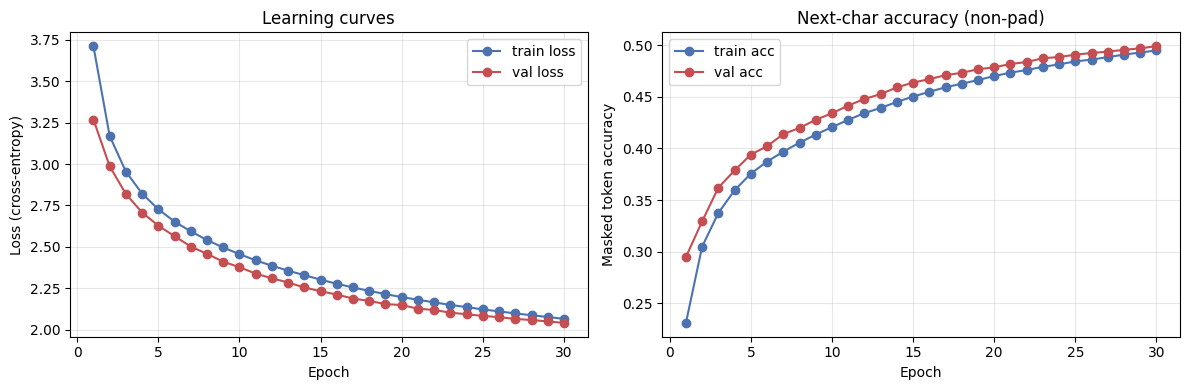

Best val_loss at epoch 30: 2.0425
Approx. val perplexity: 7.7
Best val_masked_token_accuracy at epoch 30: 49.9%


In [19]:
#@title Plot training & validation loss
if "history" not in dir() or history is None:
    print("Run the Train cell first to populate `history`.")
else:
    h = history.history
    epochs_ran = range(1, len(h.get("loss", [])) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_ran, h["loss"], "o-", label="train loss", color="#4C72B0")
    if "val_loss" in h:
        axes[0].plot(epochs_ran, h["val_loss"], "o-", label="val loss", color="#C44E52")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (cross-entropy)")
    axes[0].set_title("Learning curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if "masked_token_accuracy" in h:
        axes[1].plot(epochs_ran, h["masked_token_accuracy"], "o-", label="train acc", color="#4C72B0")
        if "val_masked_token_accuracy" in h:
            axes[1].plot(epochs_ran, h["val_masked_token_accuracy"], "o-", label="val acc", color="#C44E52")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Masked token accuracy")
        axes[1].set_title("Next-char accuracy (non-pad)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    elif "learning_rate" in h:
        axes[1].plot(epochs_ran, h["learning_rate"], "s-", color="#55A868")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Learning rate")
        axes[1].set_title("LR schedule")
        axes[1].set_yscale("log")
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    if "val_loss" in h and len(h["val_loss"]) > 1:
        best_epoch = int(np.argmin(h["val_loss"]) + 1)
        print(f"Best val_loss at epoch {best_epoch}: {min(h['val_loss']):.4f}")
        print(f"Approx. val perplexity: {np.exp(min(h['val_loss'])):.1f}")
    if "val_masked_token_accuracy" in h:
        best_acc_ep = int(np.argmax(h["val_masked_token_accuracy"]) + 1)
        print(f"Best val_masked_token_accuracy at epoch {best_acc_ep}: {max(h['val_masked_token_accuracy']):.1%}")

## Save Tokenizers + Meta

In [20]:

#@title Save artifacts
with open(os.path.join(out_dir, "src_tokenizer.pkl"), "wb") as f:
    pickle.dump(src_tok, f)
with open(os.path.join(out_dir, "tgt_tokenizer.pkl"), "wb") as f:
    pickle.dump(tgt_tok, f)
meta = {
    "src_col": src_col, "tgt_col": tgt_col, "token_level": token_level,
    "max_src_len": int(dyn_max_src), "max_tgt_len": int(dyn_max_tgt),
    "bos_char": BOS_CHAR if token_level == "char" else "<s>",
    "eos_char": EOS_CHAR if token_level == "char" else "</s>",
    "optimizer": "adam", "learning_rate": learning_rate,
    "dropout": dropout, "emb_dropout": emb_dropout, "recurrent_dropout": recurrent_dropout,
    "label_smoothing": label_smoothing,
    "decode_method": decode_method, "beam_width": beam_width,
    "beam_length_penalty": beam_length_penalty,
    "beam_min_length_ratio": beam_min_length_ratio,
}
with open(os.path.join(out_dir, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("Artifacts saved in:", out_dir)


Artifacts saved in: /Users/metasebiya21/work-projects/geez-amharic-translator/artifacts


In [21]:
print("Source vocab seen:", len(src_tok.word_index))
print("Target vocab seen:", len(tgt_tok.word_index))

Source vocab seen: 316
Target vocab seen: 340


## Inference decoder (beam search default)

**After training (same kernel):** run **Decoder helpers** below, then **Sample predictions** / **Evaluate BLEU**.

**Config:** `decode_method = "beam"` (default), `beam_width = 5`, `beam_length_penalty` (try **1.0**), `beam_min_length_ratio` (blocks ultra-short beam outputs). Use `greedy` for fast debugging. Re-run this cell after changing decode settings. **Regularization** requires **retrain** if you change `build_model`.

In [36]:
#@title Decoder helpers (beam + greedy)
def load_translator_checkpoint(filepath):
    """Load local best_model.keras (Keras 3 needs safe_mode=False for Lambda layers)."""
    if "MODEL_CUSTOM_OBJECTS" not in dir():
        raise RuntimeError(
            "Run the **Build model** cell once this session before loading a checkpoint."
        )
    return tf.keras.models.load_model(
        filepath,
        custom_objects=MODEL_CUSTOM_OBJECTS,
        safe_mode=False,
        compile=False,
    )

def assert_model_weights_finite(model):
    for v in model.trainable_weights:
        arr = v.numpy()
        if not np.isfinite(arr).all():
            raise RuntimeError(
                f"Model weights are NaN/Inf ({v.name}). Retrain with USE_MIXED_PRECISION=False."
            )

def _infer_src_shape(model):
    input_spec = model.input_shape
    if isinstance(input_spec, list):
        for spec in input_spec:
            if spec is not None:
                return spec[1:]
        raise ValueError("Cannot infer source shape from model.input_shape list.")
    if input_spec is None:
        raise ValueError("Model input shape is None; ensure the model is built.")
    return input_spec[1:]

def build_encoder_subgraph(model):
    src_shape = _infer_src_shape(model)
    src_input = tf.keras.Input(shape=src_shape, dtype="int32", name="enc_src_input")
    enc_emb = model.get_layer("src_emb")(src_input)
    bilstm = model.get_layer("bilstm")
    enc_blstm, f_h, f_c, b_h, b_c = bilstm(enc_emb)
    state_h = model.get_layer("enc_state_h")([f_h, b_h])
    state_c = model.get_layer("enc_state_c")([f_c, b_c])
    map_h = model.get_layer("map_h")(state_h)
    map_c = model.get_layer("map_c")(state_c)
    return tf.keras.Model(src_input, [enc_blstm, map_h, map_c], name="encoder_subgraph")

_ENCODER_CACHE = {}

def get_encoder_model(model, rebuild=False):
    """Cache encoder subgraph so BLEU / batch decode does not retrace predict 200×."""
    key = id(model)
    if rebuild or key not in _ENCODER_CACHE:
        _ENCODER_CACHE[key] = build_encoder_subgraph(model)
    return _ENCODER_CACHE[key]

def _decode_argmax(logits_1d, forbidden_ids, penalty_ids=None, penalty_amount=0.0):
    """Argmax next token; never pick pad (0), BOS, or other forbidden ids."""
    logits = np.asarray(logits_1d, dtype=np.float32).reshape(-1).copy()
    if not np.isfinite(logits).any():
        raise RuntimeError("Decoder logits are all NaN/Inf — retrain the model (see assert_model_weights_finite).")
    for i in forbidden_ids:
        if i is not None and 0 <= i < logits.shape[0]:
            logits[i] = -1e9
    if penalty_ids and penalty_amount > 0:
        for i in penalty_ids:
            if i is not None and 0 <= i < logits.shape[0]:
                logits[i] -= penalty_amount
    return int(np.argmax(logits))

def greedy_decode(
    model, src_seq, src_tok, tgt_tok, max_src_len, max_tgt_len, enc_model=None,
    repeat_penalty=None, repeat_window=None, stop_repeat=None,
):
    if len(src_seq) == 0:
        src_seq = [src_tok.word_index.get("<unk>", 0)]
    if enc_model is None:
        enc_model = get_encoder_model(model)
    src_seq = pad_sequences([src_seq], maxlen=max_src_len, padding="post", dtype="int32")
    enc_outputs, h, c = enc_model(src_seq, training=False)
    enc_outputs = tf.convert_to_tensor(enc_outputs)
    keys = model.get_layer("Wk")(enc_outputs)
    src_mask = model.get_layer("src_mask")(tf.convert_to_tensor(src_seq))

    dec_emb_layer = model.get_layer("tgt_emb")
    dec_lstm = model.get_layer("dec_lstm")
    Wq_layer = model.get_layer("Wq")
    attn_scores = model.get_layer("attn_scores")
    apply_mask = model.get_layer("apply_src_mask")
    softmax_layer = model.get_layer("alphas")
    context_layer = model.get_layer("context")
    attn_concat = model.get_layer("attn_concat")
    dropout = model.get_layer("dropout")
    logits_td = model.get_layer("logits")

    index2word = {i: w for w, i in tgt_tok.word_index.items()}
    index2word[0] = "<pad>"
    start_id, end_id = target_bos_eos_ids(tgt_tok)
    if start_id is None or end_id is None:
        raise RuntimeError("Missing BOS/EOS in target tokenizer — re-run Tokenizers cell.")

    if repeat_penalty is None:
        repeat_penalty = globals().get("decode_repeat_penalty", 2.5)
    if repeat_window is None:
        repeat_window = globals().get("decode_repeat_window", 12)
    if stop_repeat is None:
        stop_repeat = globals().get("decode_stop_repeat", 3)

    y = np.array([[start_id]], dtype="int32")
    out_tokens = []
    for _ in range(max_tgt_len):
        y_emb = dec_emb_layer(y)
        dec_out, h, c = dec_lstm(y_emb, initial_state=[h, c])
        queries = Wq_layer(dec_out)
        scores = attn_scores([queries, keys])
        masked_scores = apply_mask([scores, src_mask])
        alphas = softmax_layer(masked_scores)
        context = context_layer([alphas, enc_outputs])
        comb = attn_concat([dec_out, context])
        comb = dropout(comb, training=False)
        logits = logits_td(comb).numpy()[0, 0]
        forbidden = {0, start_id}
        pen_ids = list(set(out_tokens[-repeat_window:])) if out_tokens and repeat_window > 0 else []
        next_id = _decode_argmax(logits, forbidden, pen_ids, repeat_penalty)
        if next_id == end_id:
            break
        if next_id == 0:
            break
        if stop_repeat > 1 and len(out_tokens) >= stop_repeat:
            if len(set(out_tokens[-stop_repeat:])) == 1:
                break
        out_tokens.append(next_id)
        y = np.array([[next_id]], dtype="int32")
    out_words = [index2word.get(i, "<unk>") for i in out_tokens if i != 0]
    joiner = "" if getattr(tgt_tok, "char_level", False) else " "
    return joiner.join(out_words)

def _log_softmax_np(logits):
    x = np.asarray(logits, dtype=np.float32).reshape(-1)
    x = x - np.max(x)
    return x - np.log(np.sum(np.exp(x)) + 1e-12)

def _length_norm_score(log_prob, length, alpha):
    if alpha is None or alpha <= 0 or length <= 0:
        return log_prob
    return log_prob / (((5.0 + length) ** alpha) / ((5.0 + 1.0) ** alpha))

def _get_decode_layers(model):
    return {
        "dec_emb": model.get_layer("tgt_emb"),
        "dec_lstm": model.get_layer("dec_lstm"),
        "Wq": model.get_layer("Wq"),
        "Wk": model.get_layer("Wk"),
        "attn_scores": model.get_layer("attn_scores"),
        "apply_mask": model.get_layer("apply_src_mask"),
        "alphas": model.get_layer("alphas"),
        "context": model.get_layer("context"),
        "attn_concat": model.get_layer("attn_concat"),
        "dropout": model.get_layer("dropout"),
        "logits_td": model.get_layer("logits"),
    }

def _decoder_step_batched(layers, y, h, c, keys, enc_outputs, src_mask):
    """One decoder step for batch B. y: (B,1) int32; h,c: (B, units)."""
    y_emb = layers["dec_emb"](y)
    dec_out, h_new, c_new = layers["dec_lstm"](y_emb, initial_state=[h, c])
    queries = layers["Wq"](dec_out)
    scores = layers["attn_scores"]([queries, keys])
    masked_scores = layers["apply_mask"]([scores, src_mask])
    alphas = layers["alphas"](masked_scores)
    context = layers["context"]([alphas, enc_outputs])
    comb = layers["attn_concat"]([dec_out, context])
    comb = layers["dropout"](comb, training=False)
    logits = layers["logits_td"](comb).numpy()[:, 0, :]
    return logits, h_new, c_new

def beam_decode(
    model, src_seq, src_tok, tgt_tok, max_src_len, max_tgt_len, enc_model=None,
    beam_width=None, length_penalty=None,
):
    beam_width = int(globals().get("beam_width", 5) if beam_width is None else beam_width)
    length_penalty = globals().get("beam_length_penalty", 1.0) if length_penalty is None else length_penalty
    repeat_penalty = float(globals().get("decode_repeat_penalty", 2.5))
    repeat_window = int(globals().get("decode_repeat_window", 12))
    if len(src_seq) == 0:
        src_seq = [src_tok.word_index.get("<unk>", 0)]
    if enc_model is None:
        enc_model = get_encoder_model(model)
    layers = _get_decode_layers(model)
    src_char_len = len(src_seq)
    min_len = max(
        4,
        int(src_char_len * float(globals().get("beam_min_length_ratio", 0.25))),
    )
    src_seq = pad_sequences([src_seq], maxlen=max_src_len, padding="post", dtype="int32")
    enc_outputs, h0, c0 = enc_model(src_seq, training=False)
    enc_outputs = tf.convert_to_tensor(enc_outputs)
    keys = layers["Wk"](enc_outputs)
    src_mask = model.get_layer("src_mask")(tf.convert_to_tensor(src_seq))

    start_id, end_id = target_bos_eos_ids(tgt_tok)
    index2word = {i: w for w, i in tgt_tok.word_index.items()}
    index2word[0] = "<pad>"
    forbidden = {0, start_id}

    # hypotheses: list of (log_prob, token_ids, h, c)
    hyps = [(0.0, [], h0, c0)]
    completed = []

    for _ in range(max_tgt_len):
        if not hyps:
            break
        all_candidates = []
        for score, toks, h_t, c_t in hyps:
            last_id = start_id if not toks else toks[-1]
            y = np.array([[last_id]], dtype=np.int32)
            logits, h_new, c_new = _decoder_step_batched(layers, y, h_t, c_t, keys, enc_outputs, src_mask)
            log_probs = _log_softmax_np(logits[0])
            for i in forbidden:
                if i is not None and 0 <= i < log_probs.shape[0]:
                    log_probs[i] = -1e9
            if toks and repeat_penalty > 0 and repeat_window > 0:
                for tid in set(toks[-repeat_window:]):
                    if 0 <= tid < log_probs.shape[0]:
                        log_probs[tid] -= repeat_penalty
            top_idx = np.argpartition(log_probs, -beam_width)[-beam_width:]
            for nid in top_idx:
                lp = float(log_probs[nid])
                if nid == end_id:
                    if len(toks) >= min_len:
                        completed.append((score + lp, toks))
                else:
                    all_candidates.append((score + lp, toks + [int(nid)], h_new, c_new))
        if not all_candidates:
            break
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        hyps = all_candidates[:beam_width]

    pool = completed if completed else [(s, t) for s, t, _, _ in hyps]
    best_score, best_toks = max(
        pool, key=lambda x: _length_norm_score(x[0], len(x[1]), length_penalty)
    )
    joiner = "" if getattr(tgt_tok, "char_level", False) else " "
    return joiner.join(index2word.get(i, "<unk>") for i in best_toks if i != 0)

def translate_sentences(
    model, sentences, src_tok, tgt_tok, max_src_len, max_tgt_len,
    decode=None, enc_model=None,
):
    decode = decode or globals().get("decode_method", "beam")
    if enc_model is None:
        enc_model = get_encoder_model(model)
    decode_fn = beam_decode if decode == "beam" else greedy_decode
    results = []
    for s in sentences:
        seqs = src_tok.texts_to_sequences([s])
        seq = seqs[0] if seqs and len(seqs[0]) else [src_tok.word_index.get("<unk>", 0)]
        pred = decode_fn(
            model, seq, src_tok, tgt_tok, max_src_len, max_tgt_len, enc_model=enc_model
        )
        results.append(pred)
    return results

def corpus_translation_metrics(hyps, refs, token_level="char"):
    """BLEU + chrF with tokenization suited to char-level Amharic."""
    from sacrebleu.metrics import CHRF

    tok = "char" if token_level == "char" else "13a"
    bleu = sacrebleu.corpus_bleu(hyps, [refs], tokenize=tok)
    chrf = CHRF(word_order=0).corpus_score(hyps, [refs]).score
    def _chars(s):
        return len(s.replace(" ", ""))
    len_ref = np.mean([_chars(r) for r in refs])
    len_hyp = np.mean([_chars(h) for h in hyps])
    return {"bleu": bleu, "chrf": chrf, "len_ref": len_ref, "len_hyp": len_hyp}


## Quick Sanity Translations

In [37]:

#@title Sample predictions
if "translate_sentences" not in dir():
    raise RuntimeError(
        "Run the **Decoder helpers** cell above first (one click), then re-run this cell."
    )
_ckpt = os.path.join(out_dir, "best_model.keras")
_use_memory = "model" in dir() and model is not None
if _use_memory:
    try:
        assert_model_weights_finite(model)
        print("Using in-memory model from training (kernel not restarted).")
    except Exception:
        _use_memory = False
if not _use_memory:
    if not os.path.isfile(_ckpt):
        raise FileNotFoundError(f"No in-memory model and no checkpoint at {_ckpt}")
    model = load_translator_checkpoint(_ckpt)
    print("Loaded checkpoint:", _ckpt)
    assert_model_weights_finite(model)
if "history" in dir() and history is not None:
    h = history.history
    if h.get("loss") and (not np.isfinite(h["loss"][-1])):
        print("WARNING: last training loss was NaN — delete artifacts/best_model.keras and retrain.")
samples = df[src_col].tolist()[:5]
print(f"Decoding with: {globals().get('decode_method', 'beam')} (beam_width={globals().get('beam_width', 5)})")
preds = translate_sentences(model, samples, src_tok, tgt_tok, dyn_max_src, dyn_max_tgt)
for s,p,t in zip(samples, preds, df[tgt_col].tolist()[:5]):
    print("SRC:", s)
    print("PRED:", p)
    print("TGT:", t)
    print("-"*80)


Using in-memory model from training (kernel not restarted).
Decoding with: beam (beam_width=5)
SRC: ወዳዊትሰ ንጉሥ ልህቀ ወኀለፈ መዋዕሊሁ ወይከድንዎ አልባሰ ወኢያመውቆ ።
PRED: ከዚያም በኋላ ወደ ኢየሱስ ጋር ተቀመጡ።
TGT: ንጉሡ ዳዊትም ሸመገለ ዕድሜውም በዛ፤ ልብስም ደረቡለት፥ ነገር ግን አይሞቀውም ነበር።
--------------------------------------------------------------------------------
SRC: ወይቤሉ ደቁ ለዳዊት ይኅሥሡ ለእግዚእነ ለንጉሥ ወለተ ድንግለ ወያምጽእዋ ኀበ ንጉሥ ወትሰክብ ምስሌሁ ወተሐቅፎ ወታስተማውቆ ወይመውቅ እግዚእነ ንጉሥ ።
PRED: እግዚአብሔርም ሙሴን እንዲህ አላቸው።
TGT: ባሪያዎቹም። ለጌታችን ለንጉሡ ድንግል ትፈለጋለች፤ በንጉሡም ፊት ቆማ ታገልግለው፥ በጌታችንም በንጉሡ ብብት ተኝታ ታሙቀው አሉት።
--------------------------------------------------------------------------------
SRC: ወኀሠሡ ወለተ ሠናይተ እምነ ኵሉ ደወለ እስራኤል ወረከቡ አቢሳሃ ሰሜናዊት ወወሰድዋ ኀበ ንጉሥ ።
PRED: ከዚያም በኋላ በእስራኤል ልጆች ጋር ሁሉ ወደ እስራኤል ልጆች በኋላ ወደ እስራኤል ልጆች በኋላ በእስራኤል ልጆች ጋር ሁለት
TGT: በእስራኤልም አገር ሁሉ የተዋበች ቈንጆ ፈለጉ፤ ሱነማይቱን አቢሳንም አገኙ፥ ወደ ንጉሡም ይዘዋት መጡ።
--------------------------------------------------------------------------------
SRC: ወነበረት ትትለአኮ ወንጉሥሰ ኢያእመራ ።
PRED: እግዚአብሔርም እንዲህ አለው።
TGT: ቈንጆይቱም እጅግ ውብ ነበረች፤

## BLEU Evaluation

On a random held-out subset (default 200 pairs). Run the **BLEU visualization** cell below for length histograms and qualitative examples.

In [38]:

#@title Evaluate BLEU
if "translate_sentences" not in dir():
    raise RuntimeError("Run **Decoder helpers** first.")
_ckpt = os.path.join(out_dir, "best_model.keras")
if "model" not in dir() or model is None:
    model = load_translator_checkpoint(_ckpt)
    print("Loaded checkpoint:", _ckpt)
else:
    print("Using in-memory model from training.")
assert_model_weights_finite(model)
eval_n = 200  #@param {type:"integer"}
eval_decode = globals().get("decode_method", "beam")  #@param ["beam", "greedy"]
idx = np.random.choice(len(df), size=min(eval_n, len(df)), replace=False)
refs = []
hyps = []
_enc = get_encoder_model(model)
for i in idx:
    s = df.iloc[i][src_col]
    t = df.iloc[i][tgt_col]
    pred = translate_sentences(
        model, [s], src_tok, tgt_tok, dyn_max_src, dyn_max_tgt,
        decode=eval_decode, enc_model=_enc,
    )[0]
    refs.append(t)
    hyps.append(pred)
metrics = corpus_translation_metrics(hyps, refs, token_level=token_level)
bleu = metrics["bleu"]
print(f"Decode: {eval_decode} | beam_width={globals().get('beam_width', 5)} | "
      f"length_penalty={globals().get('beam_length_penalty', 1.0)} | "
      f"min_len_ratio={globals().get('beam_min_length_ratio', 0.25)}")
print(f"Mean output len: {metrics['len_hyp']:.0f} chars  (reference: {metrics['len_ref']:.0f}, spaces stripped)")
print(f"Corpus BLEU (tokenize={'char' if token_level == 'char' else '13a'}): {bleu.score:.2f}")
print(f"Corpus chrF: {metrics['chrf']:.2f}")


Using in-memory model from training.
Decode: beam | beam_width=5 | length_penalty=1.0 | min_len_ratio=0.25
Mean output len: 32 chars  (reference: 79)
Corpus BLEU (tokenize=char): 4.00
Corpus chrF: 7.30


### BLEU and translation quality

**BLEU** scores n-gram overlap (0–100). For **char-level** models we use `tokenize='char'`. Also watch **chrF** (often more informative for Amharic char MT).

Very low BLEU with **short** predictions usually means beam length bias (fixed via `beam_min_length_ratio` / `beam_length_penalty`) or genuine mismatch — check mean output length vs reference.

BLEU is imperfect (synonyms score low) but useful for tracking progress across training runs.

**Perplexity** (related to loss): \(\exp(\text{loss})\) ≈ “average branching factor” per token — lower is better.

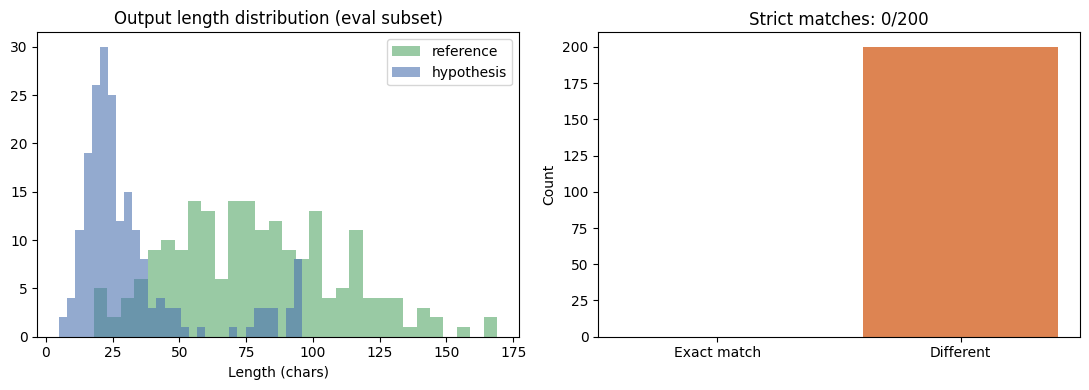

Corpus BLEU: 4.00  |  chrF: 7.30
Train perplexity (approx): 7.9

--- Qualitative samples (first 3) ---

REF: የሚ​ያ​ው​ኩ​አ​ች​ሁም ሊለዩ ይገ​ባል።ለነ​ጻ​ነት ስለ መጠ​ራት
HYP: እን​ዲ​ህም አላ​ቸው።

REF: በሬህ በፊትህ ይታረዳል፥ ከእርሱም አትበላም፤ አህያህ ከእጅህ በግድ ይወሰዳል፥ ወደ አንተም አይመለስም፤ በግህ ለጠላቶችህ ትሰጣለች፥ የሚያድንህም አታገኝም።
HYP: እርስዋም። እነሆ፥ እንዲህ አለ።

REF: እናንተ ዛሬ በአቢብ ወር ወጥታችኋል።
HYP: እግዚአብሔርም እንዲህ አለ።


In [39]:
#@title Visualize BLEU sample (predictions vs references)
if "hyps" not in dir() or "refs" not in dir():
    print("Run the Evaluate BLEU cell first.")
else:
    lengths_ref = [len(r.split()) if token_level == "word" else len(r) for r in refs]
    lengths_hyp = [len(h.split()) if token_level == "word" else len(h) for h in hyps]
    if "metrics" in dir():
        chrf = metrics["chrf"]
    else:
        from sacrebleu.metrics import CHRF
        chrf = CHRF(word_order=0).corpus_score(hyps, [refs]).score

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(lengths_ref, bins=30, alpha=0.6, label="reference", color="#55A868")
    axes[0].hist(lengths_hyp, bins=30, alpha=0.6, label="hypothesis", color="#4C72B0")
    axes[0].set_xlabel("Length (" + ("chars" if token_level == "char" else "words") + ")")
    axes[0].set_title("Output length distribution (eval subset)")
    axes[0].legend()

    # Exact match rate (strict; usually low for MT)
    exact = sum(1 for h, r in zip(hyps, refs) if h.strip() == r.strip())
    axes[1].bar(["Exact match", "Different"], [exact, len(hyps) - exact], color=["#C44E52", "#DD8452"])
    axes[1].set_title(f"Strict matches: {exact}/{len(hyps)}")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
    print(f"Corpus BLEU: {bleu.score:.2f}  |  chrF: {chrf:.2f}")
    print(f"Train perplexity (approx): {np.exp(min(history.history['loss'])):.1f}" if "history" in dir() else "")

    # Show a few examples for qualitative review
    print("\n--- Qualitative samples (first 3) ---")
    for i in range(min(3, len(hyps))):
        print(f"\nREF: {refs[i][:200]}")
        print(f"HYP: {hyps[i][:200] or '(empty)'}")

## Batch Translate a File
Default: `artifacts/geez_input.txt` (one Ge'ez sentence per line; header lines like `gez` are skipped). Set `batch_sample_n > 0` only to translate random **training CSV** rows instead of the file. For ~1k+ lines use `batch_max_lines` first to test speed.

In [42]:
#@title Batch translate (TXT or CSV sample → CSV)
from datetime import datetime
from pathlib import Path

if "translate_sentences" not in dir():
    raise RuntimeError("Run **Decoder helpers** first.")
if "model" not in dir() or model is None:
    model = load_translator_checkpoint(os.path.join(out_dir, "best_model.keras"))

def load_geez_lines_from_txt(path):
    """Read one sentence per line; skip blank lines and CSV-style headers (gez, amh, eng)."""
    skip_headers = {"gez", "amh", "eng", "source", "target"}
    lines = []
    with Path(path).open("r", encoding="utf-8") as f:
        for line in f:
            s = line.strip()
            if not s or s.lower() in skip_headers:
                continue
            lines.append(s)
    return lines

batch_txt_path = "artifacts/geez_input.txt"  #@param {type:"string"}
batch_sample_n = 0  #@param {type:"integer"}  # >0 uses training CSV instead of file
batch_max_lines = 0  #@param {type:"integer"}  # 0 = all lines; try 20 first for speed test
batch_txt_path = batch_txt_path.strip()
src_lines = None

if batch_txt_path:
    txt_path = Path(batch_txt_path).expanduser()
    if not txt_path.is_absolute():
        txt_path = (repo_root / txt_path).resolve()
    if not txt_path.exists():
        raise FileNotFoundError(f"TXT not found: {txt_path}")
    src_lines = load_geez_lines_from_txt(txt_path)
    print(f"Read {len(src_lines)} Ge'ez lines from {txt_path}")
elif batch_sample_n > 0:
    if "df" not in dir():
        raise RuntimeError("Load data first, or set batch_txt_path.")
    n = min(int(batch_sample_n), len(df))
    pick = np.random.choice(len(df), size=n, replace=False)
    src_lines = [df.iloc[i][src_col] for i in pick]
    print(f"Translating {n} random rows from training CSV (AGE).")
elif files is not None:
    print("Upload a .txt with one sentence per line...")
    uploaded_txt = files.upload()
    txt_path = Path(list(uploaded_txt.keys())[0])
    src_lines = load_geez_lines_from_txt(txt_path)
else:
    _geez_txt = repo_root / "artifacts" / "geez_input.txt"
    print("Nothing to translate. Set:")
    print(f"  batch_txt_path = '{_geez_txt}'")
    print("  or batch_sample_n = 10  (random AGE.csv lines)")

if src_lines:
    if batch_max_lines > 0:
        src_lines = src_lines[: int(batch_max_lines)]
        print(f"Limiting to first {len(src_lines)} lines (batch_max_lines).")
    _enc = get_encoder_model(model)
    _decode = globals().get("decode_method", "beam")
    print(f"Translating {len(src_lines)} lines ({_decode}) — may take a while...")
    hyps = []
    for _i, _s in enumerate(src_lines):
        if _i and _i % 50 == 0:
            print(f"  ... {_i}/{len(src_lines)}")
        hyps.append(
            translate_sentences(
                model, [_s], src_tok, tgt_tok, dyn_max_src, dyn_max_tgt,
                decode=_decode, enc_model=_enc,
            )[0]
        )
    out_csv = str(
        repo_root / "artifacts" / f"translations_kufale_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    )
    pd.DataFrame({src_col: src_lines, tgt_col: hyps}).to_csv(out_csv, index=False, encoding="utf-8")
    print("Saved:", out_csv)


Read 1270 Ge'ez lines from /Users/metasebiya21/work-projects/geez-amharic-translator/artifacts/geez_input.txt
Translating 1270 lines (beam) — may take a while...
  ... 50/1270
  ... 100/1270
  ... 150/1270
  ... 200/1270
  ... 250/1270
  ... 300/1270
  ... 350/1270
  ... 400/1270
  ... 450/1270
  ... 500/1270
  ... 550/1270
  ... 600/1270
  ... 650/1270
  ... 700/1270
  ... 750/1270
  ... 800/1270
  ... 850/1270
  ... 900/1270
  ... 950/1270
  ... 1000/1270
  ... 1050/1270
  ... 1100/1270
  ... 1150/1270
  ... 1200/1270
  ... 1250/1270
Saved: /Users/metasebiya21/work-projects/geez-amharic-translator/artifacts/translations_kufale_20260605_000116.csv


## Reload Saved Model
Load from checkpoint and reuse the same tokenizers.

In [43]:

#@title Reload best checkpoint
reloaded = load_translator_checkpoint(os.path.join(out_dir, "best_model.keras"))
assert_model_weights_finite(reloaded)
print("Reloaded.")
# Sanity test
test_src = df[src_col].iloc[0]
print("SRC:", test_src)
print("PRED:", translate_sentences(reloaded, [test_src], src_tok, tgt_tok, dyn_max_src, dyn_max_tgt)[0])


RuntimeError: Run the **Build model** cell once this session before loading a checkpoint.

## Tips for speed / memory (M1 8 GB)
- Keep `M1_8GB_MODE = True` and `token_level = "char"`.
- If OOM persists: set `batch_size = 8`, or `sample_frac = 0.5` while debugging.
- Close other apps; restart the kernel before training to clear leaked tensors.
- `FREE_ARRAYS_AFTER_PIPELINE = True` avoids keeping duplicate NumPy + tf.data in RAM.
- Mixed precision (`USE_MIXED_PRECISION`) cuts activation memory on Metal.
- Use the checkpoint `.keras` file for inference, not the in-memory model after long sessions.